# 01 — Exploration du jeu de données (IRM cérébrales)
Objectif : comprendre la structure du dataset, convertir les labels en **binaire** (tumeur vs non‑tumeur), vérifier la qualité des fichiers et analyser les résolutions d’images.

**Dataset** : `sartajbhuvaji/brain-tumor-classification-mri` (Kaggle).

## 1) Imports et configuration
- `pathlib` : parcours des dossiers
- `PIL` : ouverture d’images
- `matplotlib` : affichage
- `Counter` : comptage des classes


In [25]:
from pathlib import Path
from collections import Counter
import random
import sys 
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import seaborn as sns
import numpy as np
from tqdm import tqdm
project_src = Path.cwd().parent / "src"
if str(project_src) not in sys.path:
    sys.path.append(str(project_src))

# Test de l'import [cite: 25]
from pinkcc_ct_seg.data.transforms import get_train_transforms
print(" Module chargé avec succès !")



 Module chargé avec succès !


## 2) Chemins des données
On suppose que le dataset est copié dans : `data/raw/brain_mri/`.

Structure attendue :
```
data/raw/brain_mri/
  Training/
    glioma_tumor/
    meningioma_tumor/
    pituitary_tumor/
    no_tumor/
  Testing/
    ... (mêmes classes)
```

In [26]:
train_dir = Path("data/raw/brain_mri/Training")
test_dir  = Path("data/raw/brain_mri/Testing")

train_dir.exists(), test_dir.exists()


(True, True)

## 3) Conversion multi‑classe → binaire (tumeur vs non‑tumeur)
- **0** = `no_tumor`
- **1** = tout le reste (`glioma_tumor`, `meningioma_tumor`, `pituitary_tumor`)

On construit une liste `items` de tuples `(chemin_image, label_binaire)`.

In [27]:
from pathlib import Path

# Path.cwd() donne le dossier actuel (project/notebooks)
# .parent remonte à la racine (project/)
project_root = Path.cwd().parent 

# Définition du chemin correct
#train_dir = project_root / "data" / "raw" / "brain_mri" / "Training"

train_dir = Path(r"C:\Users\Ange\OneDrive\Desktop\Brain_tumor_mri_classification\notebooks\data\raw\brain_mri\Training")

# Vérification de sécurité
if not train_dir.exists():
    print(f" Erreur : Le dossier n'existe pas à l'emplacement : {train_dir}")
else:
    print(f" Dossier trouvé : {train_dir}")

 Dossier trouvé : C:\Users\Ange\OneDrive\Desktop\Brain_tumor_mri_classification\notebooks\data\raw\brain_mri\Training


In [28]:
items = []

for cls_dir in train_dir.iterdir():
    if not cls_dir.is_dir():
        continue

    label = 0 if cls_dir.name == "no_tumor" else 1

    for img_path in cls_dir.glob("*"):
        if img_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
            items.append((str(img_path), label))

len(items), items[:3]


(2870,
 [('C:\\Users\\Ange\\OneDrive\\Desktop\\Brain_tumor_mri_classification\\notebooks\\data\\raw\\brain_mri\\Training\\glioma_tumor\\gg (1).jpg',
   1),
  ('C:\\Users\\Ange\\OneDrive\\Desktop\\Brain_tumor_mri_classification\\notebooks\\data\\raw\\brain_mri\\Training\\glioma_tumor\\gg (10).jpg',
   1),
  ('C:\\Users\\Ange\\OneDrive\\Desktop\\Brain_tumor_mri_classification\\notebooks\\data\\raw\\brain_mri\\Training\\glioma_tumor\\gg (100).jpg',
   1)])

## 4) Distribution des classes (binaire)
On vérifie l’équilibre (ou le déséquilibre) entre `no_tumor` et `tumor`.

In [29]:
counts = Counter([label for _, label in items])
counts


Counter({1: 2475, 0: 395})

### Pourquoi tu vois souvent des tumeurs dans l’échantillon ?
Si tu observes `Counter({1: 2475, 0: 395})`, c’est **normal** :
- le dataset est **très déséquilibré** (beaucoup plus d’images « tumeur »).
- donc `random.sample(items, 6)` retourne souvent des images label **1**.

Pour afficher un échantillon plus représentatif, on échantillonne **par classe**.

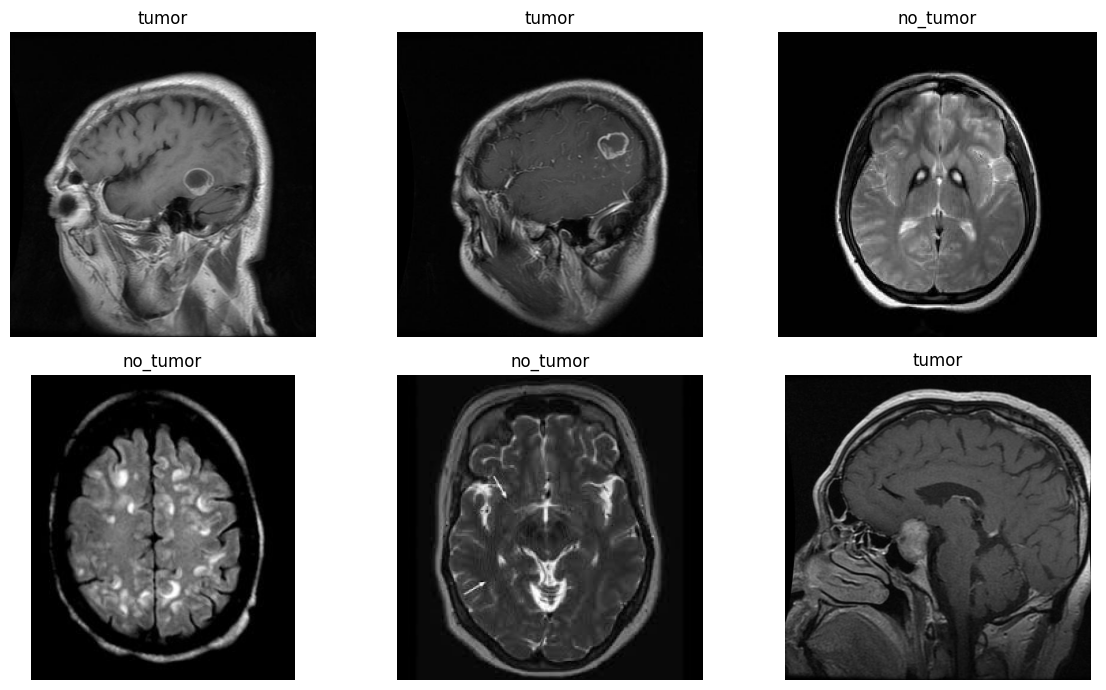

In [30]:
items_0 = [x for x in items if x[1] == 0]
items_1 = [x for x in items if x[1] == 1]

sample = random.sample(items_0, k=min(3, len(items_0))) + random.sample(items_1, k=min(3, len(items_1)))
random.shuffle(sample)

plt.figure(figsize=(12, 7))
for i, (path, label) in enumerate(sample):
    img = Image.open(path)
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title("no_tumor" if label == 0 else "tumor")
    plt.axis("off")
plt.tight_layout()
plt.show()


## 5) Vérification qualité : images corrompues, modes, tailles
On collecte :
- `img.mode` (RGB, L…)
- `img.size` = (largeur, hauteur)
- `bad` = nb d’images illisibles (exceptions)

In [31]:
sizes = []
modes = Counter()
bad = 0

for path, label in items:
    try:
        img = Image.open(path)
        sizes.append(img.size)  # (w, h)
        modes[img.mode] += 1
    except Exception:
        bad += 1

bad, modes, sizes[:3]


(0, Counter({'RGB': 2870}), [(512, 512), (512, 512), (512, 512)])

## 6) Résolutions : min / max + percentiles
Utile pour décider d’un `Resize` (ex: 256×256) dans les transformations PyTorch.

In [32]:
widths  = [w for w, h in sizes]
heights = [h for w, h in sizes]

print("min width:", min(widths))
print("max width:", max(widths))
print("min height:", min(heights))
print("max height:", max(heights))


min width: 180
max width: 1375
min height: 198
max height: 1446


In [33]:
np.percentile(widths,  [0, 25, 50, 75, 100]), np.percentile(heights, [0, 25, 50, 75, 100])


(array([ 180.,  512.,  512.,  512., 1375.]),
 array([ 198.,  512.,  512.,  512., 1446.]))

### Lecture des percentiles
Si les percentiles 25/50/75 valent **512**, c’est que **la majorité** des images sont en 512×512.

Pour la **Phase 1 (classification)** : `Resize(256,256)` est un bon compromis vitesse/détails.
Le `Resize` doit rester dans les `transforms` au moment du `Dataset`/`DataLoader`.

## 7)  Vérification rapide du dossier Testing

In [34]:
from pathlib import Path

# On définit la racine du projet en remontant d'un niveau par rapport au dossier 'notebooks'
project_root = Path.cwd()

# Définition des chemins absolus vers les données 
#train_dir = project_root / "data" / "raw" / "brain_mri" / "Training"
#test_dir = project_root / "data" / "raw" / "brain_mri" / "Testing"
train_dir = project_root / "data" / "raw" / "brain_mri" / "Training"
test_dir = project_root / "data" / "raw" / "brain_mri" / "Testing"

print(train_dir)
print(test_dir)

print(train_dir.exists())
print(test_dir.exists())

# Vérification de sécurité pour éviter le crash de la boucle iterdir()
if not test_dir.exists():
    raise FileNotFoundError(f"Le dossier de test est introuvable à l'adresse : {test_dir.absolute()}")

print(f" Dossier de test trouvé : {test_dir}")

C:\Users\Ange\OneDrive\Desktop\Brain_tumor_mri_classification\notebooks\data\raw\brain_mri\Training
C:\Users\Ange\OneDrive\Desktop\Brain_tumor_mri_classification\notebooks\data\raw\brain_mri\Testing
True
True
 Dossier de test trouvé : C:\Users\Ange\OneDrive\Desktop\Brain_tumor_mri_classification\notebooks\data\raw\brain_mri\Testing


In [35]:
test_items = []

for cls_dir in test_dir.iterdir():
    if not cls_dir.is_dir():
        continue
    label = 0 if cls_dir.name == "no_tumor" else 1
    for img_path in cls_dir.glob("*"):
        if img_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
            test_items.append((str(img_path), label))

len(test_items), Counter([y for _, y in test_items])


(394, Counter({1: 289, 0: 105}))

## 8) Analyse des résolutions et Validation des Augmentations

📊 Analyse des résolutions en cours...


Vérification des fichiers: 100%|█████████████████████████████████████████████████| 2870/2870 [00:01<00:00, 1668.10it/s]


  Intégrité des fichiers : OK.


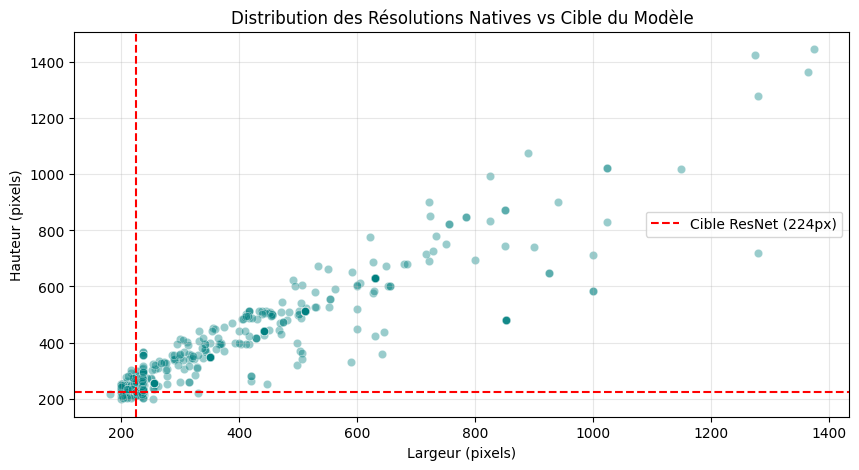

Stats - Largeur min: 180, Max: 1375
Stats - Hauteur min: 198, Max: 1446

  Test des transformations 'Advanced'...


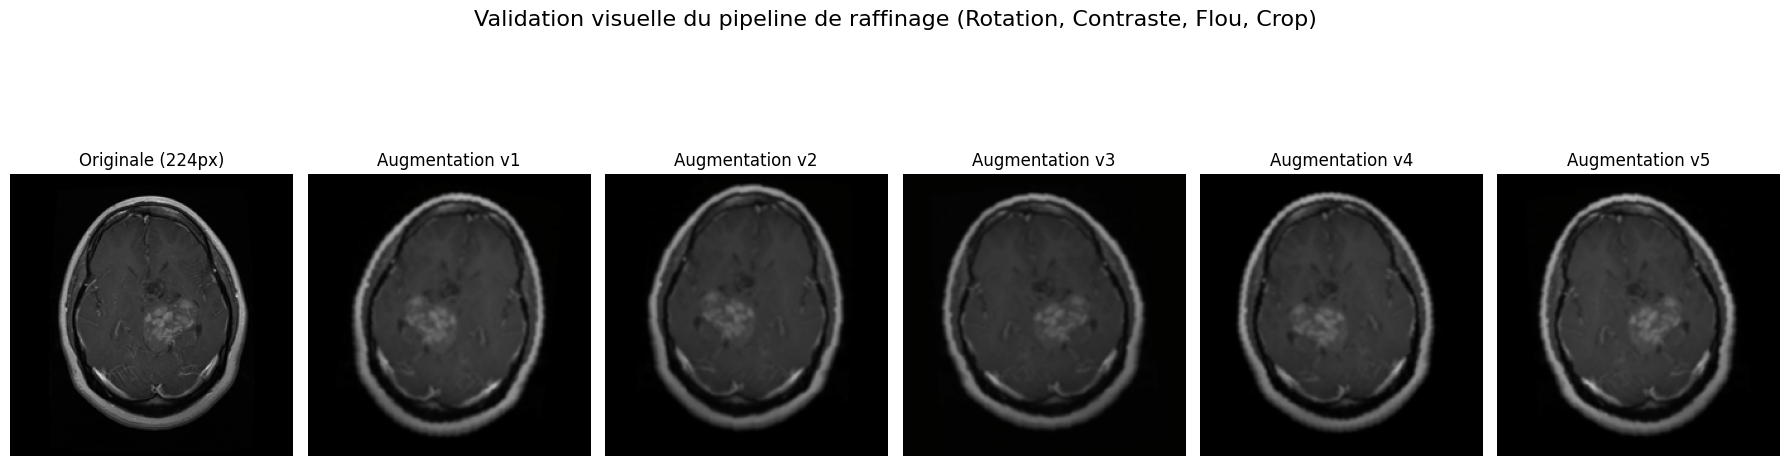

In [36]:


# --- 1. Analyse des Résolutions Natives ---
print("📊 Analyse des résolutions en cours...")
dims = []
corrupted_files = []

# Correction : On utilise 'items' qui contient vos (path, label) 
# issus des cellules précédentes du notebook
for img_path, label in tqdm(items, desc="Vérification des fichiers"):
    try:
        with Image.open(img_path) as img:
            w, h = img.size
            dims.append({'Largeur': w, 'Hauteur': h})
    except Exception as e:
        corrupted_files.append((img_path, str(e)))

dim_df = pd.DataFrame(dims)

if corrupted_files:
    print(f" Alerte : {len(corrupted_files)} fichiers corrompus détectés !")
else:
    print("  Intégrité des fichiers : OK.")

# Visualisation des dimensions
plt.figure(figsize=(10, 5))
sns.scatterplot(data=dim_df, x='Largeur', y='Hauteur', alpha=0.4, color='teal')
plt.axvline(224, color='red', linestyle='--', label='Cible ResNet (224px)')
plt.axhline(224, color='red', linestyle='--')
plt.title("Distribution des Résolutions Natives vs Cible du Modèle")
plt.xlabel("Largeur (pixels)")
plt.ylabel("Hauteur (pixels)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Stats - Largeur min: {dim_df['Largeur'].min()}, Max: {dim_df['Largeur'].max()}")
print(f"Stats - Hauteur min: {dim_df['Hauteur'].min()}, Max: {dim_df['Hauteur'].max()}")

# --- 2. Visualisation des Augmentations de Données ---
print("\n  Test des transformations 'Advanced'...")

# Sélection d'une image d'exemple (on cherche une tumeur, label 1 ou 'yes')
# On utilise la liste 'items' au lieu de 'df'
sample_path = None
for path, label in items:
    if label == 1 or label == 'yes': # S'adapte à votre encodage
        sample_path = path
        break

if sample_path is None: sample_path = items[0][0] # Fallback sur la première image

img_pil = Image.open(sample_path).convert("RGB")

# Utilise le code modifié dans transforms.py
train_transform = get_train_transforms(img_size=224, augmentation_level='advanced')

plt.figure(figsize=(18, 6))

# Affichage de l'originale
plt.subplot(1, 6, 1)
plt.imshow(img_pil.resize((224, 224)))
plt.title("Originale (224px)")
plt.axis('off')

# Affichage de 5 variantes augmentées
for i in range(2, 7):
    img_t = train_transform(img_pil)
    
    # Denormalisation pour l'affichage
    img_np = img_t.permute(1, 2, 0).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_np = (img_np * std) + mean
    img_np = np.clip(img_np, 0, 1) 
    
    plt.subplot(1, 6, i)
    plt.imshow(img_np)
    plt.title(f"Augmentation v{i-1}")
    plt.axis('off')

plt.suptitle("Validation visuelle du pipeline de raffinage (Rotation, Contraste, Flou, Crop)", fontsize=16)
plt.tight_layout()
plt.show()

##  Prochaines étapes 
1. `Dataset` PyTorch + `DataLoader`
2. `transforms`: Resize + Normalize (et augmentations)
3. Split `train/val` (stratifié)
4. Baseline modèle (ex: ResNet18)
5. Métriques adaptées au déséquilibre : F1, recall, ROC-AUC
